# CareWave — 재실/비재실 분류 모델 학습

**입력**: `csi_features_occupied.csv`, `csi_features_unoccupied.csv`  
**출력**: `model.pkl`, `feature_cols.pkl`

> VS Code 로컬 실행 시: CSV를 이 노트북과 같은 폴더(`ml/`)에 넣으면 됨  
> Colab 실행 시: 파일 업로드 셀에서 CSV 업로드

In [3]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('실행 환경:', 'Colab' if IN_COLAB else 'VS Code / 로컬')

실행 환경: VS Code / 로컬


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style='whitegrid', palette='muted')
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 업로드 & 로드

In [7]:
# Colab 에서만 업로드 창 표시
if IN_COLAB:
    from google.colab import files
    print('csi_features_occupied.csv 와 csi_features_unoccupied.csv 를 업로드하세요.')
    uploaded = files.upload()
else:
    print('로컬 실행 — ml/ 폴더의 CSV를 바로 읽습니다.')

로컬 실행 — ml/ 폴더의 CSV를 바로 읽습니다.


In [8]:
df_occ   = pd.read_csv('csi_features_occupied.csv')
df_unocc = pd.read_csv('csi_features_unoccupied.csv')
df = pd.concat([df_occ, df_unocc], ignore_index=True).dropna()

print(f'전체 데이터: {len(df):,}행')
print(f'  재실(occupied)   : {(df["label"]=="occupied").sum():,}행')
print(f'  비재실(unoccupied): {(df["label"]=="unoccupied").sum():,}행')
print(f'\n안테나별 분포:')
print(df.groupby(["label", "rx"]).size().unstack(fill_value=0))
df.head()

전체 데이터: 1,036행
  재실(occupied)   : 511행
  비재실(unoccupied): 525행

안테나별 분포:
rx          RX1  RX2  RX3
label                    
occupied    283  114  114
unoccupied  291  117  117


,label,rx,start,rssi_mean,rssi_std,amp_mean,amp_std_time,subcarrier_var_mean,subcarrier_std_mean,temporal_diff_mean_abs,...,window_var,spectral_total_power,low_band_ratio,mid_band_ratio,dominant_freq_idx,corr_mean_abs,spectral_entropy,peak_to_peak,skewness,kurtosis
0,occupied,RX1,0,-51.41,2.549882,12.755260,0.937255,26.182396,5.022369,0.238494,...,0.878446,0.878446,0.426344,0.531198,0.039062,0.386827,5.071572,6.794178,-3.967906,18.931644
1,occupied,RX1,100,-53.79,5.409797,12.445948,1.000094,13.210880,3.565874,0.264542,...,1.000188,1.000188,0.551648,0.413671,0.007812,0.487967,4.566562,6.669925,-2.657709,10.856581
2,occupied,RX3,0,-53.14,1.334316,11.473900,0.768564,23.278519,4.773427,0.170315,...,0.590691,0.590691,0.416470,0.535627,0.070312,0.449191,5.286767,5.505182,-4.384678,21.975912
3,occupied,RX2,0,-53.87,3.576744,13.328327,0.878349,23.424632,4.747016,0.222816,...,0.771498,0.771498,0.364426,0.588592,0.007812,0.493326,5.187164,6.275967,-4.294589,21.642731
4,occupied,RX1,200,-53.67,5.006106,13.057389,0.869221,19.991805,4.352136,0.229092,...,0.755545,0.755545,0.351098,0.600338,0.039062,0.370773,5.125586,6.033948,-4.487495,22.519604


## 2. 탐색적 데이터 분석 (EDA)

In [9]:
key_features = ['window_var', 'amp_std_time', 'spectral_entropy',
                 'peak_to_peak', 'subcarrier_var_mean', 'corr_mean_abs']
df.groupby('label')[key_features].mean().T.round(4)

label,occupied,unoccupied
window_var,0.8214,0.6791
amp_std_time,0.9042,0.8209
spectral_entropy,5.1058,5.1901
peak_to_peak,6.2458,5.8181
subcarrier_var_mean,20.6627,20.6924
corr_mean_abs,0.4425,0.5987


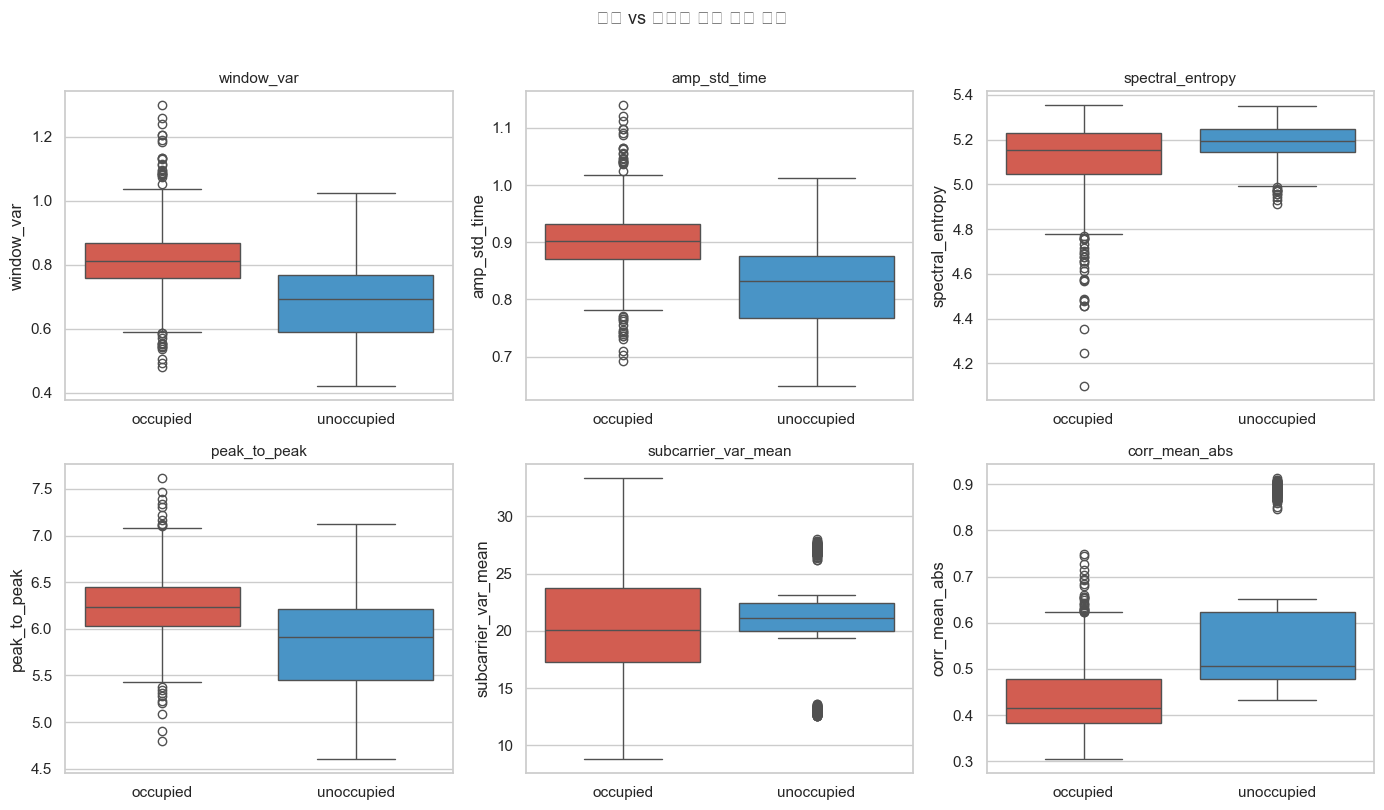

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='label', y=feat, ax=axes[i],
                palette={'occupied': '#e74c3c', 'unoccupied': '#3498db'})
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('재실 vs 비재실 주요 특징 분포', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

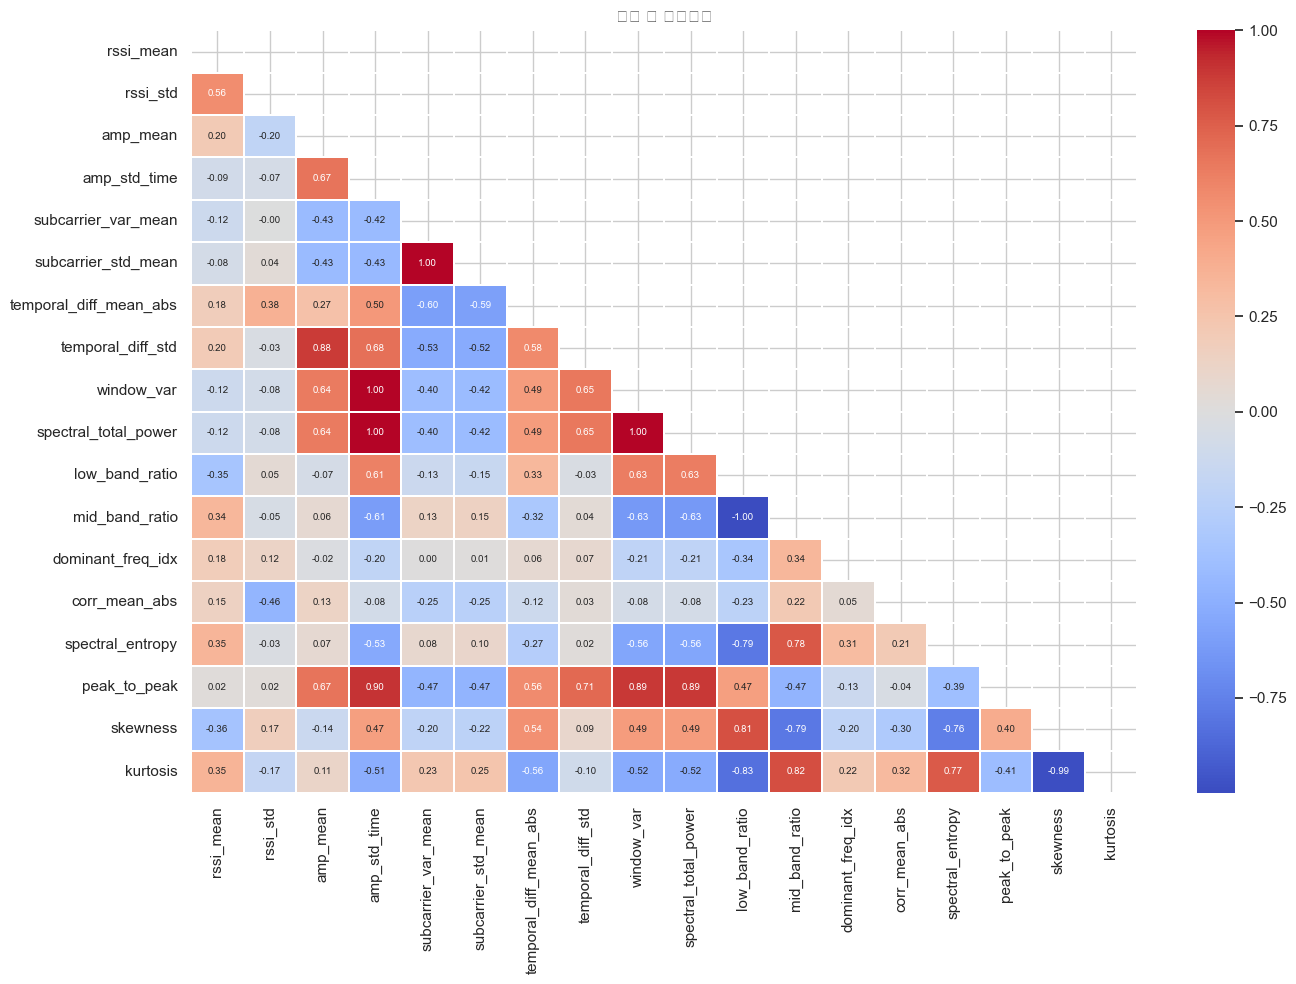

In [11]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'start']
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('특징 간 상관관계')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 전처리

In [12]:
# spectral_total_power == window_var (동일값 중복) 제거
# start 는 윈도우 인덱스 — 예측과 무관하여 제거
# rx 는 One-Hot 인코딩

DROP_COLS = ['label', 'start', 'spectral_total_power']

df_encoded = pd.get_dummies(df, columns=['rx'], prefix='rx')
feature_cols = [c for c in df_encoded.columns if c not in DROP_COLS]

X = df_encoded[feature_cols].astype(float)
y = (df['label'] == 'occupied').astype(int)  # 1=재실, 0=비재실

print(f'사용 특징 수: {len(feature_cols)}')
print(feature_cols)

사용 특징 수: 20
['rssi_mean', 'rssi_std', 'amp_mean', 'amp_std_time', 'subcarrier_var_mean', 'subcarrier_std_mean', 'temporal_diff_mean_abs', 'temporal_diff_std', 'window_var', 'low_band_ratio', 'mid_band_ratio', 'dominant_freq_idx', 'corr_mean_abs', 'spectral_entropy', 'peak_to_peak', 'skewness', 'kurtosis', 'rx_RX1', 'rx_RX2', 'rx_RX3']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습: {len(X_train)}행 | 테스트: {len(X_test)}행')

학습: 828행 | 테스트: 208행


## 4. 모델 학습 & 교차검증

In [14]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"모델":<22} {"CV 정확도 (평균+-표준편차)":<30} {"테스트 정확도"}')
print('-' * 65)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'model': model, 'cv_mean': cv_scores.mean(),
                     'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f'{name:<22} {cv_scores.mean():.4f} +- {cv_scores.std():.4f}               {test_acc:.4f}')

모델                     CV 정확도 (평균+-표준편차)              테스트 정확도
-----------------------------------------------------------------
Random Forest          0.9964 +- 0.0048               1.0000
Gradient Boosting      0.9904 +- 0.0135               1.0000
SVM (RBF)              0.9976 +- 0.0048               1.0000
Logistic Regression    0.9903 +- 0.0099               1.0000


## 5. 최적 모델 평가

In [15]:
best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
print(f'최적 모델: {best_name}  (테스트 정확도: {results[best_name]["test_acc"]:.4f})')
y_pred = best_model.predict(X_test)

최적 모델: Random Forest  (테스트 정확도: 1.0000)


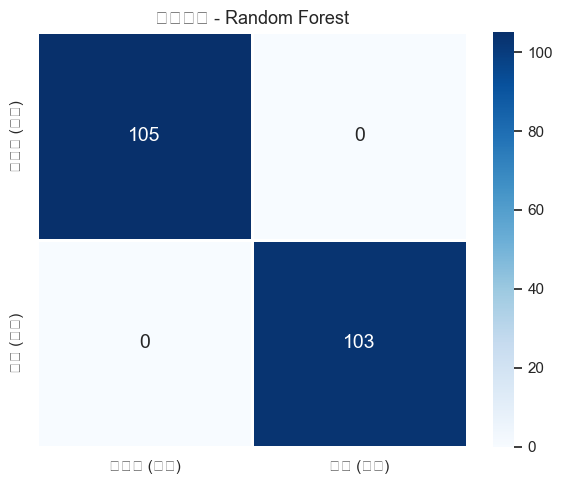

TP(재실->재실)  : 103  |  FP(비재실->재실): 0
FN(재실->비재실): 0  |  TN(비재실->비재실): 105


In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=['비재실 (예측)', '재실 (예측)'],
            yticklabels=['비재실 (실제)', '재실 (실제)'],
            ax=ax, annot_kws={'size': 14})
ax.set_title(f'혼동행렬 - {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP(재실->재실)  : {tp}  |  FP(비재실->재실): {fp}')
print(f'FN(재실->비재실): {fn}  |  TN(비재실->비재실): {tn}')

In [17]:
print('=== 분류 리포트 ===')
print(classification_report(y_test, y_pred, target_names=['비재실', '재실'], digits=4))

=== 분류 리포트 ===
              precision    recall  f1-score   support

         비재실     1.0000    1.0000    1.0000       105
          재실     1.0000    1.0000    1.0000       103

    accuracy                         1.0000       208
   macro avg     1.0000    1.0000    1.0000       208
weighted avg     1.0000    1.0000    1.0000       208



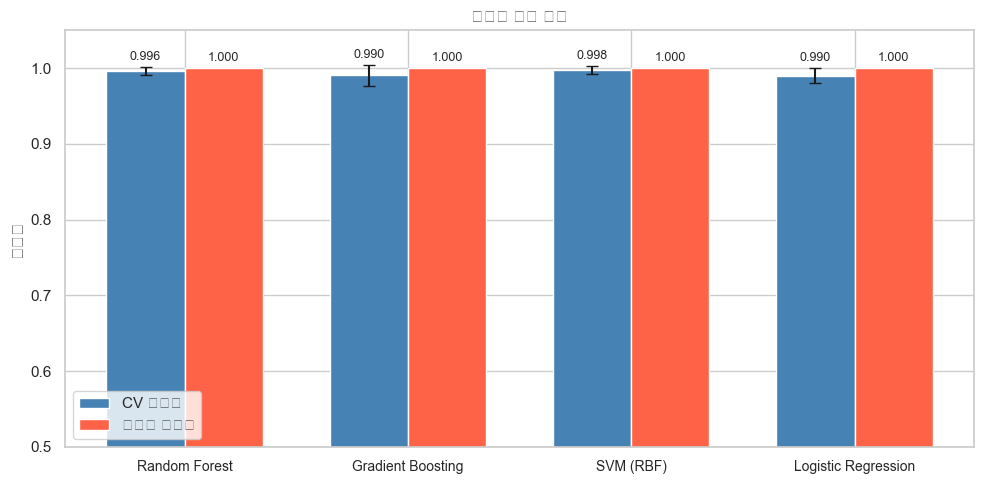

In [18]:
names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
cv_means  = [results[n]['cv_mean']  for n in names]
cv_stds   = [results[n]['cv_std']   for n in names]

x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_means,  width, label='CV 정확도',   color='steelblue', yerr=cv_stds, capsize=4)
bars2 = ax.bar(x + width/2, test_accs, width, label='테스트 정확도', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('정확도')
ax.set_title('모델별 성능 비교')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 특징 중요도 (Random Forest)

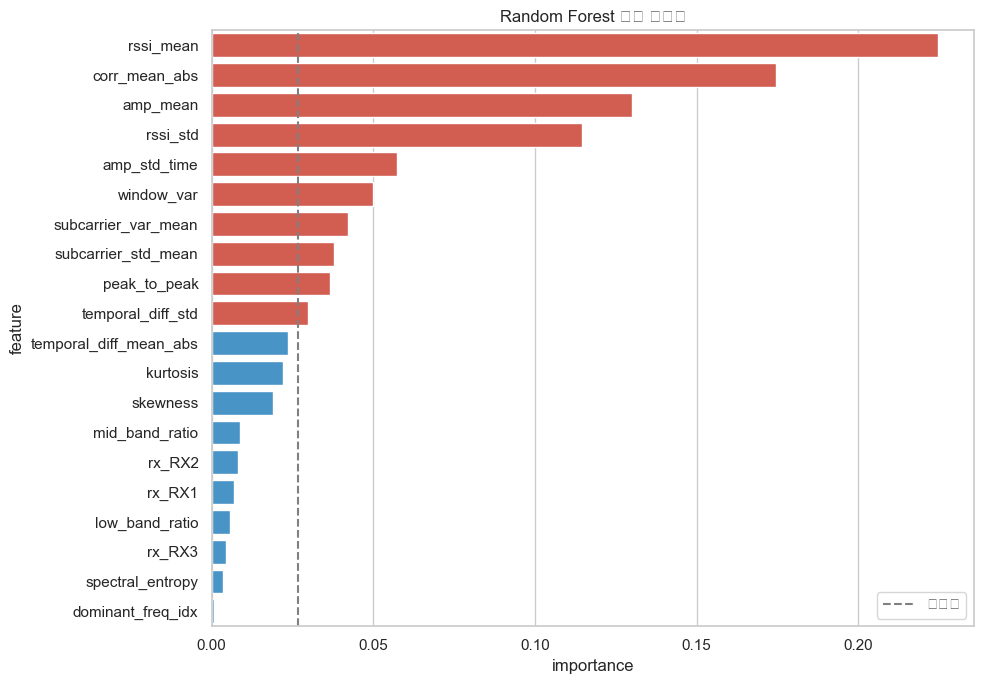


상위 5개 특징:
      feature  importance
    rssi_mean    0.224615
corr_mean_abs    0.174467
     amp_mean    0.130164
     rssi_std    0.114463
 amp_std_time    0.057472


In [19]:
rf_model    = results['Random Forest']['model']
feat_df     = pd.DataFrame({'feature': feature_cols, 'importance': rf_model.feature_importances_})
feat_df     = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > feat_df['importance'].median() else '#3498db'
          for v in feat_df['importance']]
sns.barplot(data=feat_df, x='importance', y='feature', palette=colors)
plt.axvline(feat_df['importance'].median(), color='gray', linestyle='--', label='중앙값')
plt.title('Random Forest 특징 중요도')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n상위 5개 특징:')
print(feat_df.head(5).to_string(index=False))

## 7. 모델 저장

In [20]:
joblib.dump(best_model,   'model.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print(f'model.pkl       저장 완료 — {best_name}')
print(f'feature_cols.pkl 저장 완료 — {len(feature_cols)}개 특징')

# Colab 이면 자동 다운로드
if IN_COLAB:
    from google.colab import files
    for f in ['model.pkl', 'feature_cols.pkl',
               'confusion_matrix.png', 'feature_importance.png', 'model_comparison.png']:
        files.download(f)
else:
    print('\nml/ 폴더에 저장됨 — model.pkl, feature_cols.pkl')

model.pkl       저장 완료 — Random Forest
feature_cols.pkl 저장 완료 — 20개 특징

ml/ 폴더에 저장됨 — model.pkl, feature_cols.pkl
